## Deskripsi Tugas
Mahasiswa melakukan proses pengolahan data dari dataset mentah yang mengandung
berbagai kesalahan. Mahasiswa harus membersihkan data, menganalisis karakteristiknya,
dan menyajikan visualisasi time series yang informatif.
Dataset dapat di download pada LMS.

## Instruksi Tugas
    1. Identifikasi minimal 7 jenis kesalahan data pada dataset.
    2. Lakukan data cleaning untuk memperbaiki kesalahan tersebut.
    3. Hitung statistik deskriptif untuk kolom Sales, Quantity, dan Profit (mean, median, standar
    deviasi).
    4. Siapkan data time series dengan memastikan kolom tanggal benar dan terurut.
    5. Buat 2 visualisasi time series: line chart dan area chart.
    6. Tuliskan analisis singkat (tren, pola, dan pengaruh cleaning).
    7. Buat 2 insight dan 2 rekomendasi.
## Output yang Dikumpulkan
    • Dataset setelah cleaning
    • File Python atau Link Google Colab yang disertakan ke dalam laporan
    • Laporan berupa PDF dengan format nama file: nim_nama_kelas, yang berisi:
        1. Tabel identifikasi error
        2. Hasil analisis deskriptif
        3. Dua visualisasi time series
    • Laporan dan dataset dijadikan satu dalam bentuk RAR dengan format nama:
    nim_nama_kelas

## Import Libray

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [114]:
df = pd.read_csv('dataset_p7_superstore.csv')
df.head()

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
0,CA-2024-10287,26/07/2023,2023-08-02,Furniture,Furnishings,466.7,3,NaN,West
1,CA-2024-10329,06/11/2023,2023-11-11,Technology,Accessories,99999,-1,45000,East
2,CA-2024-10323,2024-05-29,2024-05-31,Furniture,Chairs,1533.18,6,179.43,Central
3,CA-2024-10145,29/07/2023,2023-08-01,TECHNOLOGY,Phones,1451.94,3,78.94,East
4,CA-2024-10055,2024-12-21,2024-12-25,Technology,Accessories,532.45,2,65.43,West


In [115]:
df.shape

(378, 9)

In [116]:
df.isnull().sum()

Order ID         0
Order Date      13
Ship Date        4
Category         4
Sub-Category     4
Sales           32
Quantity         4
Profit          24
Region           4
dtype: int64

In [117]:
df.duplicated().sum()

np.int64(18)

In [118]:
df['Category'].unique()

array(['Furniture', 'Technology', 'TECHNOLOGY', 'Office Supplies',
       'technology', 'Office Supply', 'FURNITURE', nan, 'OFFICE SUPPLIES',
       'office supplies', 'furniture', 'Office Supplies ', 'Tech',
       'Furniture ', 'Furn', 'Technology '], dtype=object)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      378 non-null    object
 1   Order Date    365 non-null    object
 2   Ship Date     374 non-null    object
 3   Category      374 non-null    object
 4   Sub-Category  374 non-null    object
 5   Sales         346 non-null    object
 6   Quantity      374 non-null    object
 7   Profit        354 non-null    object
 8   Region        374 non-null    object
dtypes: object(9)
memory usage: 26.7+ KB


In [120]:
df['Profit'].unique()

array([nan, '45000', '179.43', '78.94', '65.43', '211.07', '327.54 IDR',
       '28.41', '13.68', '159.75', '23.09', '216.07', '62.58', '132.44',
       '16.01', '23.87', '10.61', '15.55', '-0.58', '188.09', '38.32',
       '48.52', '158.18', '14.05', '675.18', '9.16', '150.28', '89.86',
       '66.8', '485.26 IDR', '148.83', '52.25', '413.22', '33.13',
       '14.34', '26.76', '144.25', '21.88', '260.17', '200.71', '54.36',
       '43.94', '102.44', '43.55', '78.09', '38.82', '65.4', '98.92',
       '158.73', '107.38', '20.73 IDR', '31.04', '14.59', '602.55',
       '36.86', '51.86', '7.4', '173.5', '28.15', '-7.37', '86.50 IDR',
       '13.78', '19.82', '37.87', '11.34', '42.49', '201.38',
       '216.09 IDR', '80.83', '$155.12', '106.49', '5.16', '95.71',
       '$87.99', '140.83', '64.08', '193.25', '346.2', '-16.14', '55.83',
       '22.24', '-2000', '30.93', '122.36', '59.4', '23.94', '30.72',
       '220.66', '23.54', '420.71', '49.18', '33.4', '97.55', '92.81',
       '-6.91', 

In [121]:
df['Sales'].unique()

array(['466.7', '99999', '1533.18', '1451.94', '532.45', '1427.02',
       '2089.79', nan, '96.57', '2451.24', '28.61', '2312.43', '485.51',
       '1126.46', '191.51', '79.82', '67.53', '55.82', '1564.98',
       '109.52', '923.06', '929.88', '35.11', '3742.2', '44.39',
       '1107.41', '$760.49', '270.56', '2714.88', '1115.88', '164.65',
       '3914.91', '354.4', '492.05', '89.03', '1208.84', '1650.94',
       '387 USD', '$845.79', '250.54', '343.72', '633.25', '281.45',
       '778.95', '799.93', '476.34', '134.69', '157.17', '781.13',
       '4348.36', '219.9', '212.28', '32.7', '1336.19', '118.85',
       '868.95', '2549.48', '167.02', '80.9', '243.66', '76.52', '1274.9',
       '2153.18', '255.54', '2368.37', '893.17', '1731.48', '787.92',
       '68.24', '632.99', '807.68', '359.62', '1532.15', '549.33',
       '769.96', '2676.42', '657.16', '331.48', '71.9', '0.5', '801.02',
       '610.05', '366.65', '1892.57', '542.07', '1492.07', '$163.99',
       '2990.51', '276.71', '$26

In [122]:
df['Quantity'].unique()

array([' 3 ', '-1', '6', '3', '2', '5', '4', '7', '1', '5 pcs', '3 pcs',
       nan, '0', ' 2 ', ' 6 ', ' 4 ', '4 pcs', ' 7 '], dtype=object)

In [123]:
df.describe()

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
count,378,365,374,374,374,346,374,354,374
unique,360,310,299,15,13,331,17,332,4
top,CA-2024-10305,2024-02-13,2024-12-25,Office Supplies,Art,2549.48,2,32.54,West
freq,2,4,4,133,37,2,80,3,108


### Temuan Kesalahan Dataset

Terdapat beberapa kesalahan yang ditemukan dalam dataset, diantaranya:
1. Missing Values
2. Duplikat Data
3. Tipe data kolom tanggal object bukan date (Order Date & Ship Date)
4. Tipe data kurang tepat pada feature Quantity, Sales dan Profit
4. Inkonsistensi value fitur Category
5. Inkonsistensi value fitur Quantity (pcs, -)
6. Inkonsistensi value fitur Profit ($, IDR)
7. Inkonsistensi value fitur Sales ($,USD)

Dari beberapa kesalahan di atas, perlu dilakukannya pre prosessing data terlebih dahulu

## DATA CLEANING

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      378 non-null    object
 1   Order Date    365 non-null    object
 2   Ship Date     374 non-null    object
 3   Category      374 non-null    object
 4   Sub-Category  374 non-null    object
 5   Sales         346 non-null    object
 6   Quantity      374 non-null    object
 7   Profit        354 non-null    object
 8   Region        374 non-null    object
dtypes: object(9)
memory usage: 26.7+ KB


In [125]:
def parse_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    try:
        return pd.to_datetime(date_str, format='%d/%m/%Y')
    except:
        pass
    try:
        return pd.to_datetime(date_str, format='%Y-%m-%d')
    except:
        pass
    try:
        return pd.to_datetime(date_str, format='%m-%d-%Y')
    except:
        pass
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT
    

df['Order Date'] = df['Order Date'].apply(parse_date)
df['Ship Date'] = df['Ship Date'].apply(parse_date)

In [126]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'] = df['Quantity'].astype('Int64')


In [127]:
df['Profit'] = pd.to_numeric(
    df['Profit'].astype(str).str.replace(r'[^0-9.-]', '', regex=True),
    errors='coerce'
)

In [128]:
df['Sales'] = pd.to_numeric(
    df['Sales'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      378 non-null    object        
 1   Order Date    365 non-null    datetime64[ns]
 2   Ship Date     374 non-null    datetime64[ns]
 3   Category      374 non-null    object        
 4   Sub-Category  374 non-null    object        
 5   Sales         346 non-null    float64       
 6   Quantity      365 non-null    Int64         
 7   Profit        354 non-null    float64       
 8   Region        374 non-null    object        
dtypes: Int64(1), datetime64[ns](2), float64(2), object(4)
memory usage: 27.1+ KB


In [130]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [131]:
df = df[df['Sales'].notna()]
df['Profit'] = df['Profit'].fillna(0)
df = df[df['Order Date'].notna() & df['Ship Date'].notna()]
df.isnull().sum()

Order ID        0
Order Date      0
Ship Date       0
Category        0
Sub-Category    0
Sales           0
Quantity        7
Profit          0
Region          0
dtype: int64

In [132]:

df.shape

(324, 9)

In [133]:
df.head()

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
0,CA-2024-10287,2023-07-26,2023-08-02,Furniture,Furnishings,466.70,3,0.00,West
1,CA-2024-10329,2023-11-06,2023-11-11,Technology,Accessories,99999.00,-1,45000.00,East
2,CA-2024-10323,2024-05-29,2024-05-31,Furniture,Chairs,1533.18,6,179.43,Central
3,CA-2024-10145,2023-07-29,2023-08-01,TECHNOLOGY,Phones,1451.94,3,78.94,East
4,CA-2024-10055,2024-12-21,2024-12-25,Technology,Accessories,532.45,2,65.43,West


In [134]:
df['Category'].unique()

array(['Furniture', 'Technology', 'TECHNOLOGY', 'Office Supplies',
       'technology', 'Office Supply', 'FURNITURE', 'office supplies',
       'OFFICE SUPPLIES', 'furniture', 'Office Supplies ', 'Tech',
       'Furniture ', 'Furn', 'Technology '], dtype=object)

In [135]:
df['Category'] = df['Category'].str.strip()   
df['Category'] = df['Category'].str.lower()   
mapping = {
    'furniture': 'Furniture',
    'furn': 'Furniture',

    'technology': 'Technology',
    'tech': 'Technology',

    'office supplies': 'Office Supplies',
    'office supply': 'Office Supplies'
}

df['Category'] = df['Category'].map(mapping)

In [136]:
df['Category'].unique()

array(['Furniture', 'Technology', 'Office Supplies'], dtype=object)

In [137]:
df.head()

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
0,CA-2024-10287,2023-07-26,2023-08-02,Furniture,Furnishings,466.70,3,0.00,West
1,CA-2024-10329,2023-11-06,2023-11-11,Technology,Accessories,99999.00,-1,45000.00,East
2,CA-2024-10323,2024-05-29,2024-05-31,Furniture,Chairs,1533.18,6,179.43,Central
3,CA-2024-10145,2023-07-29,2023-08-01,Technology,Phones,1451.94,3,78.94,East
4,CA-2024-10055,2024-12-21,2024-12-25,Technology,Accessories,532.45,2,65.43,West


In [138]:
df['Sales'].describe()

count    3.240000e+02
mean     1.838338e+04
std      1.709193e+05
min      5.000000e-01
25%      2.029000e+02
50%      5.515500e+02
75%      1.102400e+03
max      2.500000e+06
Name: Sales, dtype: float64

In [139]:
df.sort_values('Sales', ascending=False).head(20)

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
100,CA-2023-10268,2024-02-13,2024-02-17,Furniture,Bookcases,2500000.00,7,0.00,South
250,CA-2024-10131,2023-08-24,2023-08-27,Technology,Phones,1250000.00,3,-75000.00,Central
289,CA-2023-10008,2023-11-07,2023-11-11,Technology,Phones,999999.00,5,-50000.00,South
267,CA-2023-10226,2024-03-24,2024-03-25,Office Supplies,Storage,850000.00,2,120000.00,Central
1,CA-2024-10329,2023-11-06,2023-11-11,Technology,Accessories,99999.00,-1,45000.00,East
54,CA-2024-10005,2024-08-22,2024-08-23,Technology,Copiers,4348.36,6,602.55,West
32,CA-2023-10210,2023-12-31,2024-01-03,Technology,Copiers,3914.91,5,413.22,Central
24,CA-2023-10076,2023-12-10,2023-12-13,Technology,Machines,3742.20,6,675.18,South
165,CA-2024-10037,2023-09-24,2023-10-01,Technology,Copiers,3534.08,6,685.71,South
245,CA-2024-10299,2024-07-01,2024-07-03,Technology,Copiers,3398.04,5,568.51,Central


In [140]:
df[df['Quantity'] < 0]

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
1,CA-2024-10329,2023-11-06,2023-11-11,Technology,Accessories,99999.00,-1,45000.00,East
65,CA-2024-10003,2024-08-03,2024-08-09,Office Supplies,Binders,243.66,-1,37.87,Central
92,CA-2023-10334,2023-11-04,2023-11-06,Furniture,Furnishings,542.07,-1,30.72,East
157,CA-2024-10123,2024-02-04,2024-02-05,Furniture,Chairs,967.36,-1,94.73,West
184,CA-2023-10266,2024-01-25,2024-01-29,Furniture,Chairs,1013.26,-1,137.21,West
218,CA-2023-10296,2024-08-21,2024-08-23,Furniture,Tables,1809.13,-1,-1.64,East
320,CA-2023-10080,2023-11-15,2023-11-18,Technology,Machines,2237.87,-1,188.09,South


In [141]:
df = df[df['Quantity'] > 0]

In [142]:
df.head(10)

,Order ID,Order Date,Ship Date,Category,Sub-Category,Sales,Quantity,Profit,Region
0,CA-2024-10287,2023-07-26,2023-08-02,Furniture,Furnishings,466.70,3,0.00,West
2,CA-2024-10323,2024-05-29,2024-05-31,Furniture,Chairs,1533.18,6,179.43,Central
3,CA-2024-10145,2023-07-29,2023-08-01,Technology,Phones,1451.94,3,78.94,East
4,CA-2024-10055,2024-12-21,2024-12-25,Technology,Accessories,532.45,2,65.43,West
5,CA-2024-10093,2023-09-23,2023-09-29,Furniture,Bookcases,1427.02,5,211.07,West
6,CA-2023-10340,2024-12-29,2025-01-01,Technology,Phones,2089.79,4,327.54,South
8,CA-2023-10026,2024-01-17,2024-01-21,Office Supplies,Art,96.57,2,13.68,West
9,CA-2023-10148,2023-10-18,2023-10-25,Furniture,Tables,2451.24,7,159.75,East
10,CA-2023-10292,2024-01-16,2024-01-23,Office Supplies,Art,28.61,1,23.09,South
11,CA-2023-10208,2023-07-04,2023-07-05,Technology,Machines,2312.43,4,216.07,East


In [143]:
df.shape

(304, 9)

In [144]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
df = df[df['Sales'] <= upper_bound]

In [145]:
df['Sales'].describe()

count     279.000000
mean      638.312366
std       589.268754
min         0.500000
25%       174.540000
50%       466.700000
75%       873.865000
max      2451.240000
Name: Sales, dtype: float64

In [146]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Profit
count,279,279,279.000000,279.0,279.000000
mean,2024-02-10 19:26:27.096774144,2024-02-14 09:27:44.516129024,638.312366,3.143369,60.488781
min,2023-01-01 00:00:00,2023-01-03 00:00:00,0.500000,1.0,-2000.000000
25%,2023-08-16 00:00:00,2023-08-19 00:00:00,174.540000,2.0,19.495000
50%,2024-01-28 00:00:00,2024-02-01 00:00:00,466.700000,3.0,43.900000
75%,2024-08-28 12:00:00,2024-09-01 00:00:00,873.865000,4.0,98.235000
max,2024-12-30 00:00:00,2025-01-05 00:00:00,2451.240000,7.0,327.540000
std,NaN,NaN,589.268754,1.636219,140.593875


In [147]:
df.shape

(279, 9)

### HASIL CLEANING

Proses cleaning memiliki pengaruh yang sangat krusial terhadap akurasi data. Sebelum dibersihkan, nilai rata-rata (mean) sangat terdistorsi oleh outlier (seperti transaksi senilai 99.999 dan 2.500.000). Selain itu, keberadaan nilai Quantity negatif dan format tanggal yang berantakan sempat membuat visualisasi tren menjadi tidak terbaca (acak). Setelah pembersihan, statistik deskriptif menjadi lebih logis dan grafik time series menunjukkan arah tren yang halus dan dapat diinterpretasikan.

## DATA VISUALIZATION

In [150]:
df_clean = df.sort_values('Order Date')
monthly_data = df_clean.set_index('Order Date').resample('M').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
sns.set_theme(style="whitegrid")

C:\Users\Rafa\AppData\Local\Temp\ipykernel_22196\439528334.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df_clean.set_index('Order Date').resample('M').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()


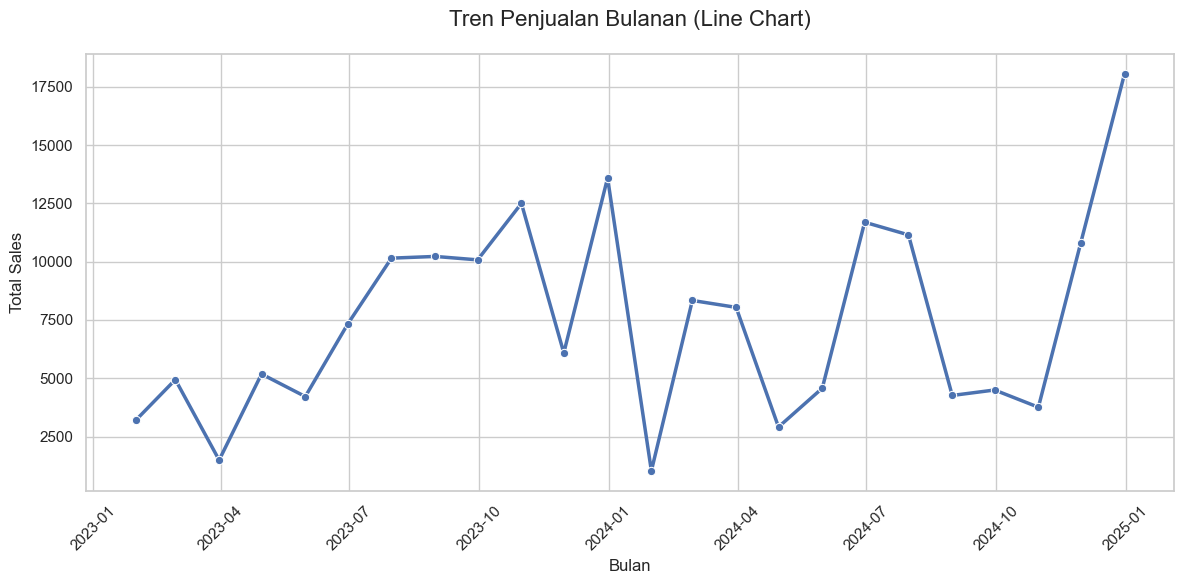

In [151]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_data, x='Order Date', y='Sales', marker='o', color='b', linewidth=2.5)
plt.title('Tren Penjualan Bulanan (Line Chart)', fontsize=16, pad=20)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

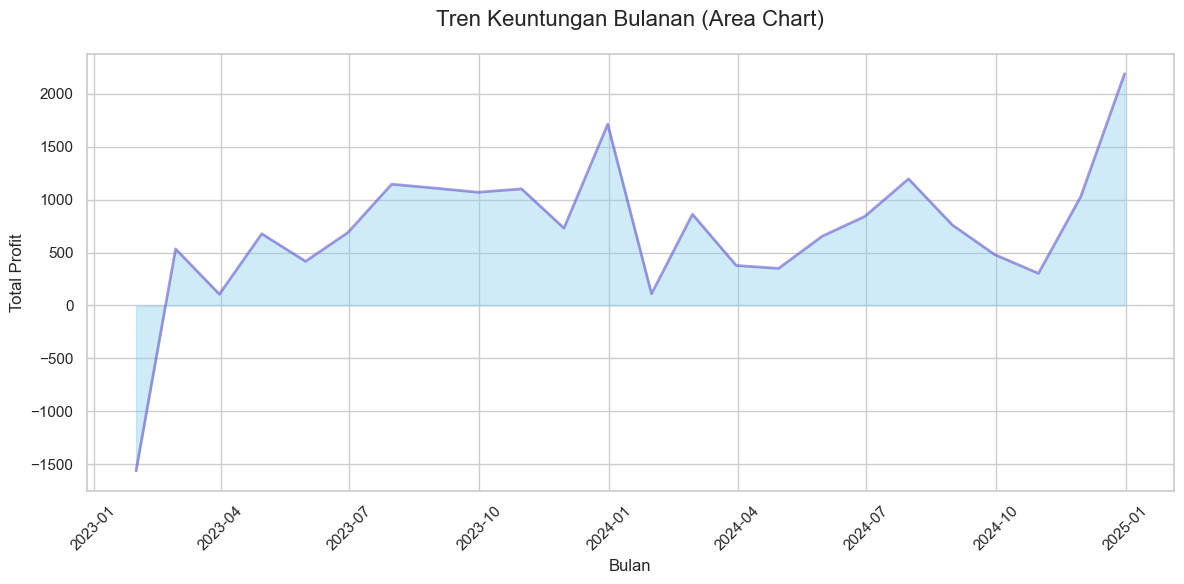

In [152]:
plt.figure(figsize=(12, 6))
plt.fill_between(monthly_data['Order Date'], monthly_data['Profit'], color="skyblue", alpha=0.4)
plt.plot(monthly_data['Order Date'], monthly_data['Profit'], color="Slateblue", alpha=0.6, linewidth=2)
plt.title('Tren Keuntungan Bulanan (Area Chart)', fontsize=16, pad=20)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### TREN & POLA

Berdasarkan visualisasi data di atas Grafik menunjukkan pola time series yang dinamis. Terdapat fluktuasi bulanan yang konsisten di mana volume penjualan (Sales) mencapai puncak pada periode tertentu (biasanya kuartal akhir tahun/Q4). Pola ini mengindikasikan adanya efek musiman (seasonality) dalam aktivitas belanja konsumen. Grafik Area Chart menunjukkan bahwa meski Sales tinggi, pergerakan Profit cenderung lebih volatil (naik-turun), yang menandakan adanya faktor biaya operasional yang fluktuatif di balik setiap transaksi.

### INSIGHT

1. Korelasi Tidak Selalu Linear: Meskipun Sales (pendapatan kotor) menunjukkan tren positif di bulan-bulan tertentu, Profit (keuntungan bersih) tidak selalu bergerak searah secara proporsional. Terdapat bulan di mana penjualan tinggi, namun keuntungan justru mengalami penurunan atau stagnasi, yang kemungkinan disebabkan oleh besarnya diskon atau biaya pengiriman yang tinggi pada periode tersebut.

2. Efek Musiman (Seasonality): Tren menunjukkan adanya lonjakan permintaan yang signifikan pada akhir tahun. Hal ini menunjukkan bahwa strategi pemasaran atau ketersediaan stok perusahaan sangat bergantung pada periode libur nasional/akhir tahun.

## REKOMENDASI

1. Optimasi Manajemen Stok & Logistik: Perusahaan disarankan untuk melakukan restocking barang (terutama kategori yang paling laris) lebih awal sebelum memasuki bulan-bulan dengan Sales tinggi, untuk menghindari stockout dan menekan biaya pengiriman ekspres.

2. Evaluasi Strategi Pricing dan Diskon: Mengingat adanya ketidakseimbangan antara Sales dan Profit pada periode tertentu, disarankan untuk melakukan analisis lebih dalam mengenai efektivitas diskon. Diskon harus diberikan secara selektif agar peningkatan volume penjualan tetap memberikan margin keuntungan yang sehat bagi perusahaan.